# Parte 4
## Task 1

Para resolver esto, lo que se necestia realizar es el método de composición. El método de composición lo que sirve es para utilizar la CDF de una o más vraibles aleatorias y al multiplicar con su probabildiad resptciva, para muestra aleatoria para distribución discreta. Cada distribución tiene x chance de que pase.

Algoritmo
1. Define la distribución de probabilidad discreta como un conjunto de resultados y sus probabilidades correspondientes.
2. Calcula la función de distribución acumulada (CDF) a partir de las probabilidades.
3. Genera una muestra aleatoria u a partir de una distribución uniforme entre 0 y 1.
4. Utiliza la CDF para encontrar el resultado correspondiente para la muestra aleatoria generada.


Pseudocódigo, no es para ejecutar

function generate_random_discrete_variable():
    # Definir distribuciones, resultados y probabilidades
    outcomes = [outcome_1, outcome_2, ..., outcome_n]
    probabilities = [p_1, p_2, ..., p_n]

    # Calcular el CDF de cada uno
    cdf = [probabilities[0]]
    for i from 1 to n-1:
        cdf.append(cdf[i-1] + probabilities[i])

    # Generar muestra aleatoria uniforme de 0 y 1
    u = random_uniform(0, 1)

    # Utilizar CDF del resultado final para la muestra aleatoria
    for i from 0 to n-1:
        if u < cdf[i]:
            return outcomes[i]

    # Devolver último paso
    return outcomes[n-1]

# Task 2
Escriba un programa tal que, dada una función de masa de probabilidad (pi para i de 1 a n), proporcione como
salida el valor de una variable aleatoria con esta función de masa. Haga un histograma para alguna distribución de
ejemplo.

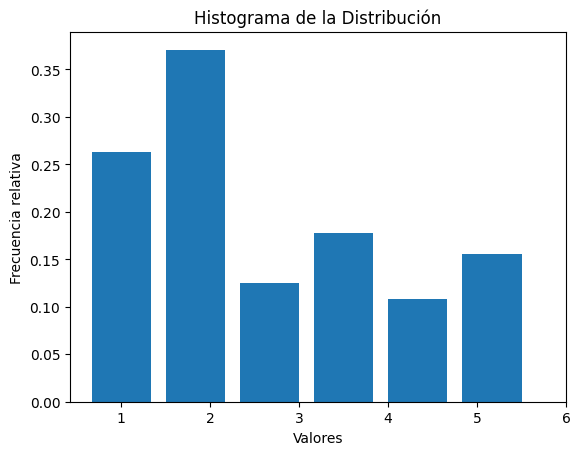

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def generate_random_variable(fmp):
    values = list(fmp.keys())
    probabilities = list(fmp.values())
    rand_var = np.random.choice(values, p=probabilities)
    return rand_var

def plot_histogram(fmp, num_samples=1000):
    samples = [generate_random_variable(fmp) for _ in range(num_samples)]

    plt.hist(samples, bins=len(fmp), rwidth=0.8, align='left', density=True)
    plt.xticks(list(fmp.keys()))
    plt.xlabel('Valores')
    plt.ylabel('Frecuencia relativa')
    plt.title('Histograma de la Distribución')
    plt.show()

masa_de_probabilidad = {
    1: 0.2,
    2: 0.3,
    3: 0.1,
    4: 0.15,
    5: 0.1,
    6: 0.15
}

plot_histogram(masa_de_probabilidad, num_samples=1000)

# Task 3
Suponga que usted es gerente de proyecto en Inversiones Chileras S.A.; y debe elegir entre dos proyectos a realizar,
la construcción de un Hotel o la construcción de de un Centro Comercial. Los flujos de caja esperados para cada
proyecto son los siguientes:

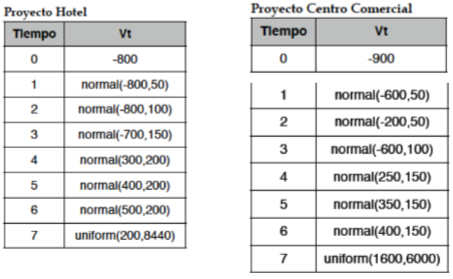

Si el parámetro que quiere utilizar para comprar ambos proyectos es el Valor Presente Neto al 10% del costo de capital.

1. Realice tres simulaciones para determinar cuál de los proyectos es el más rentable. Utilice 100, 1,000 y
10,000 iteraciones


In [3]:
import numpy as np

def calcular_vpn(flujos_caja, tasa_descuento):
    return np.sum([flujo / (1 + tasa_descuento) ** t for t, flujo in enumerate(flujos_caja)])

def simulacion(iteraciones, flujos_hotel, flujos_centro_comercial, tasa_descuento):
    vpns_hotel = []
    vpns_centro_comercial = []

    for i in range(iteraciones):
        flujos_hotel_simulacion = [np.random.normal(mu, sigma) if sigma else mu for mu, sigma in flujos_hotel]
        flujos_centro_comercial_simulacion = [np.random.normal(mu, sigma) if sigma else mu for mu, sigma in flujos_centro_comercial]

        vpns_hotel.append(calcular_vpn(flujos_hotel_simulacion, tasa_descuento))
        vpns_centro_comercial.append(calcular_vpn(flujos_centro_comercial_simulacion, tasa_descuento))

    vpn_promedio_hotel = np.mean(vpns_hotel)
    vpn_promedio_centro_comercial = np.mean(vpns_centro_comercial)

    return vpn_promedio_hotel, vpn_promedio_centro_comercial

flujos_hotel = [(-800, 0), (-800, 50), (-800, 100), (-700, 150), (300, 200), (400, 200), (500, 200), (200, 8440)]
flujos_centro_comercial = [(-900, 0), (-600, 50), (-200, 50), (-600, 100), (250, 150), (350, 150), (400, 150), (1600, 6000)]

tasa_descuento = 0.1

iteraciones = [100, 1000, 10000]

for it in iteraciones:
    vpn_hotel, vpn_centro_comercial = simulacion(it, flujos_hotel, flujos_centro_comercial, tasa_descuento)
    print(f"Resultados con {it} iteraciones:")
    print(f"  - Hotel: VPN = {vpn_hotel}")
    print(f"  - Centro Comercial: VPN = {vpn_centro_comercial}")
    print(f"  - Proyecto más rentable: {'Hotel' if vpn_hotel > vpn_centro_comercial else 'Centro Comercial'}")
    print()


Resultados con 100 iteraciones:
  - Hotel: VPN = -1641.7996126970306
  - Centro Comercial: VPN = -1064.604569886522
  - Proyecto más rentable: Centro Comercial

Resultados con 1000 iteraciones:
  - Hotel: VPN = -1757.102245173549
  - Centro Comercial: VPN = -597.0318701822002
  - Proyecto más rentable: Centro Comercial

Resultados con 10000 iteraciones:
  - Hotel: VPN = -1901.8156351972364
  - Centro Comercial: VPN = -596.2814672633534
  - Proyecto más rentable: Centro Comercial

